In [132]:
"""
Use aimsgb to generate grain boundaries, then use 
GPUMD to relax such structures into realistic configurations.
"""
from dotenv import load_dotenv
from aimsgb import GrainBoundary, Grain
from ase.visualize import view
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
import numpy as np
import math
load_dotenv()

s_input = Grain.from_mp_id("mp-149")  # Silicon

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Probe cell lengths: [55.51508925 27.75754463  5.44370237], stacking direction: 0
UC_A = UC_B = 1, repeat = (2, 10, 1)
Cell lengths before permutation: [55.51508925 27.75754463  5.44370237]
Final cell lengths (x, y, z): [55.51508925 54.43702373 55.51508925]
Final cell matrix:
[[55.51508925  0.          0.        ]
 [ 0.         54.43702373  0.        ]
 [ 0.          0.         55.51508925]]
Number of atoms: 8320


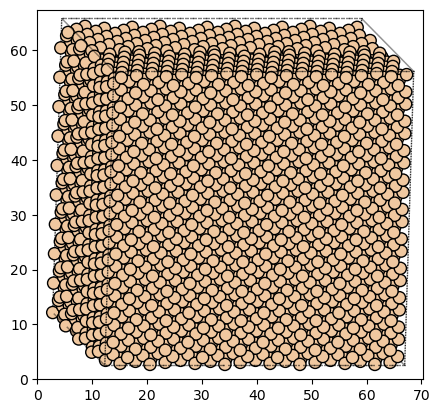

In [ ]:
# In Lortaraprasert and Shiomi 2022, they use:
# 1. Sigma 5 (2 -1 0) [0 0 1]
# 2. Sigma 9 (-1 -2 1) [1 1 0]
# 3. Sigma 9 (2 -2 1) [2 1 2]
# 4. Sigma 3 (1 -1 2) [1 1 0]
# 5. Sigma 5 (3 1 0) [3 1 0]
# 6. Sigma 13 (1 0 0) [1 0 0]
GB_LIST = [
    ((1, 0, 0), 13, (0, -5, 1)),
]
BOX_SIZE = np.array([50, 50, 50])

def build_gb_atoms(s_input, axis, sigma, plane):
    # --- Probe build: uc_a=uc_b=1 to get base dimensions ---
    gb_probe = GrainBoundary(axis, sigma, plane, s_input, uc_a=1, uc_b=1)
    structure_probe = Grain.stack_grains(
        gb_probe.grain_a, gb_probe.grain_b,
        direction=gb_probe.direction, to_primitive=False
    )
    atoms_probe = structure_probe.to_ase_atoms()
    probe_lengths = atoms_probe.cell.lengths()
    d = gb_probe.direction
    print(f"Probe cell lengths: {probe_lengths}, stacking direction: {d}")

    # --- Determine the axis permutation ---
    if d == 0:
        perm = [1, 2, 0]
    elif d == 1:
        perm = [0, 2, 1]
    else:
        perm = [0, 1, 2]

    # --- Compute multipliers ---
    # After permutation: new_x = old[perm[0]], new_y = old[perm[1]], new_z = old[d]
    # UC controls z (stacking), repeat controls x and y (in-plane)
    UC = max(int(np.ceil(BOX_SIZE[2] / probe_lengths[d])), 1)
    scale_x = max(int(np.ceil(BOX_SIZE[0] / probe_lengths[perm[0]])), 1)
    scale_y = max(int(np.ceil(BOX_SIZE[1] / probe_lengths[perm[1]])), 1)
    print(f"UC_A = UC_B = {UC}, repeat = ({scale_x}, {scale_y}, 1)")

    # --- Real build with correct UC ---
    gb = GrainBoundary(axis, sigma, plane, s_input, uc_a=UC, uc_b=UC)
    structure = Grain.stack_grains(
        gb.grain_a, gb.grain_b,
        direction=gb.direction,
        to_primitive=False
    )
    atoms = structure.to_ase_atoms()
    print(f"Cell lengths before permutation: {atoms.cell.lengths()}")

    # --- Permute so stacking direction → z ---
    if d != 2:
        new_cell = atoms.cell[perm][:, perm]
        new_positions = atoms.positions[:, perm]
        atoms.set_cell(new_cell, scale_atoms=False)
        atoms.set_positions(new_positions)

    # --- In-plane tiling ---
    atoms = atoms.repeat((scale_x, scale_y, 1))

    # --- Clean up any tiny off-diagonal elements ---
    cell = atoms.cell[:]
    np.fill_diagonal(cell, np.diag(cell))  # keep diagonal
    off_diag_mask = ~np.eye(3, dtype=bool)
    cell[off_diag_mask] = 0.0
    atoms.set_cell(cell, scale_atoms=False)

    atoms.pbc = True
    atoms.wrap()

    print(f"Final cell lengths (x, y, z): {atoms.cell.lengths()}")
    print(f"Final cell matrix:\n{atoms.cell[:]}")
    print(f"Number of atoms: {len(atoms)}")
    return atoms, multipliers

for (axis, sigma, plane) in GB_LIST:
    atoms, multipliers = build_gb_atoms(s_input, axis, sigma, plane)

    fig, ax = plt.subplots()
    plot_atoms(atoms, ax=ax, rotation="10x,10y,0z")
    # view(atoms)

# then convert to ASE atoms, write into GPUMD format
# use SW potential with cooling ramp to relax structure (4000K to 25K over 1275ps, simulation step 1fs)
# then a final energy relaxation using L-BFGS
# repeat this process 10 times and get the most energetically stable structure